In [1]:
import pandas as pd
import numpy as np
import math
import statsmodels.api as sm
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import datetime
from scipy import stats
import warnings
import datetime
import os
from datetime import datetime
warnings.filterwarnings('ignore')
import matplotlib as mpl
warnings.filterwarnings("ignore")
mpl.rcParams['xtick.labelsize'] = 12
mpl.rcParams['ytick.labelsize'] = 12
mpl.rcParams['font.size'] = 12

In [2]:
# 0 -- 6 month
# 1 -- 2 year
# 2 -- 5 year
# 3 -- 10 year

rate_reg = 3
window_size = 373

In [3]:
load_path = r'\\osiride-fs\group\main\891af\private\Area_MF\Varie\Poli_Venturi\Data\Database_Regression.xlsx'
mergedData = pd.read_excel(load_path,index_col=[0],parse_dates=[0])
mergedData = mergedData.loc[datetime(2000,1,1):datetime(2025,1,1),[
    'SwapESTR6Md','SwapESTR2Yd','SwapESTR5Yd','SwapESTR10Yd',
    'SwapESTR6Mm','SwapESTR2Ym','SwapESTR5Ym','SwapESTR10Ym',
    'OASd','EASurprise','USSurprise'
]]
mergedData.dropna(inplace=True)
    
diff_rates_clean = mergedData.loc[:,['SwapESTR6Md','SwapESTR2Yd','SwapESTR5Yd','SwapESTR10Yd']]

z = np.abs(stats.zscore(diff_rates_clean))
threshold = 10

outliers = pd.concat([diff_rates_clean[z.SwapESTR6Md>threshold],diff_rates_clean[z.SwapESTR2Yd>threshold],
                     diff_rates_clean[z.SwapESTR5Yd>threshold],diff_rates_clean[z.SwapESTR10Yd>threshold],
                     diff_rates_clean.loc[datetime(2023,3,13):datetime(2023,3,15)]],axis=0)

outliers.reset_index(inplace=True,drop=False)
outliers.drop_duplicates(subset='Date',inplace=True)
outliers.sort_values(by='Date',inplace=True,ignore_index=True)
outliers.set_index('Date',inplace=True,drop=True)

diff_rates_clean.drop(outliers.index,inplace=True,axis=0)

idx = diff_rates_clean.index

mergedData = mergedData.loc[idx]

In [4]:
ratevol_estr = mergedData.loc[:,['SwapESTR6Md','SwapESTR2Yd','SwapESTR5Yd','SwapESTR10Yd']].fillna(method='ffill').rolling(window=5,closed='left').std()
ratevol_estr = (ratevol_estr - ratevol_estr.mean())/ratevol_estr.std()
for j in ratevol_estr.columns:
    ratevol_estr.rename(columns={j: j.replace('Yd','Yv')},inplace=True)
    ratevol_estr.rename(columns={j: j.replace('Md','Mv')},inplace=True)

diff_rates_estr = mergedData.loc[:,['SwapESTR6Md','SwapESTR2Yd','SwapESTR5Yd','SwapESTR10Yd']]

df_momentum_estr = mergedData.loc[:,['SwapESTR6Mm','SwapESTR2Ym','SwapESTR5Ym','SwapESTR10Ym']]
df_momentum_estr.fillna(method='ffill',inplace=True)
df_momentum_estr = (df_momentum_estr - df_momentum_estr.mean())/df_momentum_estr.std()

diff_oas = mergedData.loc[:,['OASd']]
diff_oas = (diff_oas - diff_oas.mean())/diff_oas.std()

df_surprise_ea = mergedData.loc[:,['EASurprise']]
df_surprise_ea = (df_surprise_ea - df_surprise_ea.mean())/df_surprise_ea.std()

df_surprise_us = mergedData.loc[:,['USSurprise']]
df_surprise_us = (df_surprise_us - df_surprise_us.mean())/df_surprise_us.std()

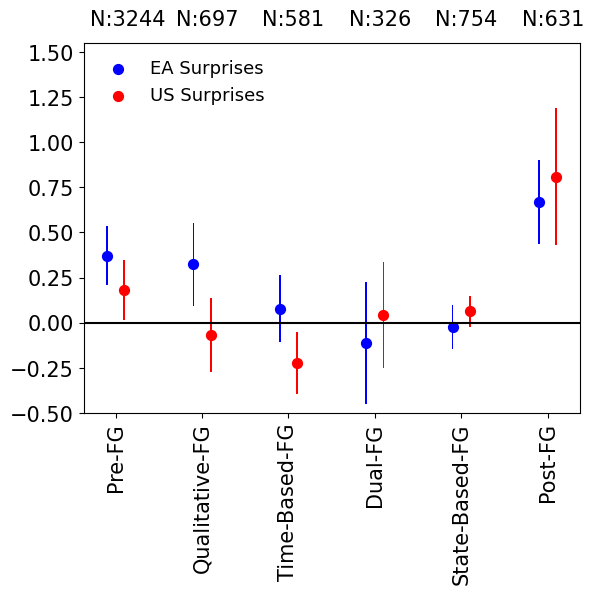

In [5]:
left = [mergedData.index[0],datetime(2013,7,1), datetime(2016,3,1), datetime(2018,6,1), datetime(2019,9,1),datetime(2022,7,21)]
right = [datetime(2013,7,1),datetime(2016,3,1), datetime(2018,6,1), datetime(2019,9,1), datetime(2022,7,21),mergedData.index[-1]]
index = ['Pre-FG','Qualitative-FG','Time-Based-FG','Dual-FG','State-Based-FG','Post-FG']
df = pd.DataFrame()
rsquared = list()
nobs = list()

for j in range(len(left)):
    df_reg = pd.concat([diff_rates_estr.iloc[:,rate_reg],
                    df_surprise_ea,df_surprise_us,
                    df_momentum_estr.iloc[:,rate_reg],ratevol_estr.iloc[:,rate_reg],diff_oas],axis=1)
    
    Y = df_reg.loc[left[j]:right[j]].iloc[:,[0]]
    X = df_reg.loc[left[j]:right[j]].iloc[:,1:]
    X = sm.add_constant(X)
    model = sm.OLS(Y, X,missing='drop').fit(cov_type='HAC',cov_kwds={'maxlags':math.ceil(0.75*len(Y)**(1/3))})
    rsquared.append(model.rsquared)
    nobs.append(model.nobs)
    dff = pd.DataFrame(data={'EA':model.params['EASurprise'],
                             'EA lb':model.conf_int(alpha=0.10).loc['EASurprise',0],
                             'EA ub':model.conf_int(alpha=0.10).loc['EASurprise',1],
                             'EA pval': model.pvalues.EASurprise,
                             'EA ttest': model.tvalues.EASurprise,
                             'US':model.params['USSurprise'],
                             'US lb':model.conf_int(alpha=0.10).loc['USSurprise',0],
                             'US ub':model.conf_int(alpha=0.10).loc['USSurprise',1],
                             'US pval': model.pvalues.USSurprise,
                             'US ttest': model.tvalues.USSurprise,
                             'Obs':model.nobs,
                             'R2':model.rsquared},
                       index=[index[j]])
    df = pd.concat([df,dff],axis=0)
    if os.path.exists('ECB_results.xlsx'):
        with pd.ExcelWriter('ECB_results.xlsx', engine='openpyxl', mode='a',if_sheet_exists='replace') as writer:
            df.round(2).to_excel(writer, sheet_name=Y.columns[0].replace('Swap','').replace('d',''))
    else:
        df.round(2).to_excel('ECB_results.xlsx',sheet_name=Y.columns[0].replace('Swap','').replace('d',''))

os.chdir(r'\\osiride-fs\group\main\891af\private\Area_MF\Varie\Poli_Venturi\Output')

barWidth = 0.2

r1 = np.arange(len(df))
r2 = [x + barWidth for x in r1]

plt.bar(r1, df['EA ub']-df['EA lb'], width=0.02, bottom=df['EA lb'],color='blue')
plt.scatter(r1,df['EA'],s=50,color='blue',label='EA Surprises')
plt.bar(r2, df['US ub']-df['US lb'], width=0.02, bottom=df['US lb'],color='red')
plt.scatter(r2,df['US'],s=50,color='red',label='US Surprises')
plt.legend(loc='upper left',fontsize=13,frameon=False)

ylim = 1.55
for j in range(len(df)):
    string = 'N:' + str(int(nobs[j]))
    plt.text(r1[j]-0.2,ylim+0.1,string,fontsize=15)
plt.xticks([r + barWidth/2 for r in range(len(df))], df.index,rotation=90)
plt.axhline(y = 0, color = 'k') 
plt.ylim(-0.5,ylim)
plt.xticks(fontsize=15)
plt.yticks(fontsize=15)

name = Y.columns[0][:-1] + '_communication'
name = name.replace('Swap','')
plt.savefig(name,bbox_inches="tight",dpi=200)